In [1]:
import matplotlib.pyplot as plt
import pyopencl as cl
import numpy as np
import cv2 as cv
import time

start_time = time.time()

try:
    plaforms = cl.get_platforms()
    global plaform
    plaform = plaforms[0]
    devices = plaform.get_devices()
    global device
    device = devices[0]
    global ctx
    ctx = cl.Context(devices) # or dev_type=cl.device_type.ALL)
    global commQ
    commQ = cl.CommandQueue(ctx,device)
    file = open("prog.c","r")
    global prog
    prog = cl.Program(ctx,file.read())
    prog.build()
except Exception as e:
    print(e)

print("- opencl setup: execute --- %s seconds ---" % (time.time() - start_time))

- opencl setup: execute --- 0.5538680553436279 seconds ---


Ex 1

- gpu: execute --- 0.020845651626586914 seconds ---


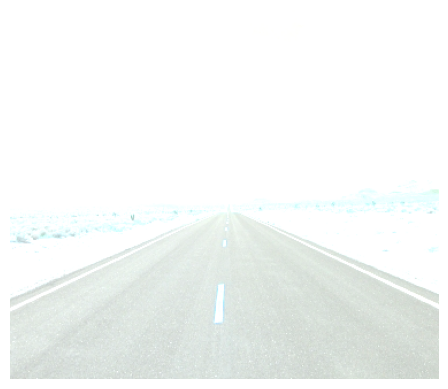

In [2]:
try:
    start_time = time.time()
    # === LOAD IMAGE ===
    img = cv.imread("Aula_6-7_files\\aula4-1.jpg")
    h, w, c = img.shape
    img_rgba = cv.cvtColor(img, cv.COLOR_BGR2BGRA)

    fmt = cl.ImageFormat(cl.channel_order.RGBA, cl.channel_type.UNORM_INT8)

    imageIn = cl.create_image(ctx, cl.mem_flags.READ_ONLY | cl.mem_flags.COPY_HOST_PTR, fmt, shape=(w, h), hostbuf=img_rgba)

    output = np.empty_like(img_rgba)
    out_buf = cl.Buffer(ctx, cl.mem_flags.WRITE_ONLY, output.nbytes)

    # === IMAGE PARAMETERS ===
    brightness = 150  # increase brightness
    contrast = 1.2   # increase contrast

    kernel = prog.brightness_and_contrast

    kernel.set_arg(0, np.int32(w))
    kernel.set_arg(1, np.int32(h))
    kernel.set_arg(2, np.int32(0))  # padding
    kernel.set_arg(3, np.int32(brightness))
    kernel.set_arg(4, np.float32(contrast))
    kernel.set_arg(5, imageIn)
    kernel.set_arg(6, out_buf)
    
    width_height_ratio = int(w/h)
    # Launch kernel (1 work-item per pixel)
    #local_work_size_var  = [width_height_ratio*32, 32]
    
    #One PC has max work_size of 32, another has a max work_size of 16 
    local_work_size_var  = [width_height_ratio*16, 16]

    cl.enqueue_nd_range_kernel(commQ, kernel, global_work_size=(int(np.ceil(w/local_work_size_var[0]))*local_work_size_var[0], int(np.ceil(h/local_work_size_var[1]))*local_work_size_var[1]), local_work_size=local_work_size_var)
    cl.enqueue_copy(commQ, output, out_buf)

    # Reshape and show result
    img_out = output.reshape(h, w, 4)

    execute_time_CB_gpu = time.time() - start_time

    print(f"- gpu: execute --- {execute_time_CB_gpu} seconds ---")

    plt.imshow(img_out)
    plt.axis('off')
    plt.show()

except Exception as e:
    print("Error:", e)

Ex 2

- cpu: execute --- 0.0031113624572753906 seconds ---


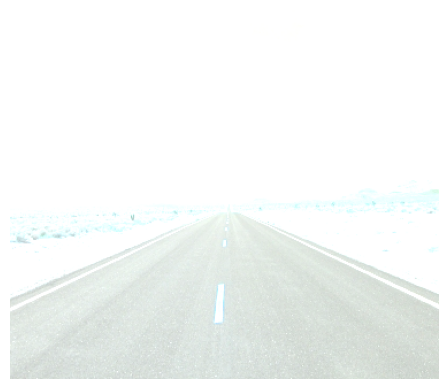

In [3]:
start_time = time.time()
img = cv.imread("Aula_6-7_files\\aula4-1.jpg")

if img is None:
    raise FileNotFoundError("Image not found. Check the path.")

# Convert to BGRA (adds alpha channel)
#img_rgba = cv.cvtColor(img, cv.COLOR_BGR2BGRA)

# === APPLY SOBEL ===

new_image = cv.convertScaleAbs(img, alpha=1.2, beta=150)

execute_time_CB_cpu = time.time() - start_time

print(f"- cpu: execute --- {execute_time_CB_cpu} seconds ---")

# === SHOW RESULT ===
plt.imshow(new_image)
plt.axis('off')
plt.show()


In [4]:
print(f"- Compare gpu exec. time with cpu exec. time --- {execute_time_CB_gpu - execute_time_CB_cpu} seconds ---")

- Compare gpu exec. time with cpu exec. time --- 0.017734289169311523 seconds ---


As the previous output is posivite then it is reasonable to assume that the GPU execution time is larger than the CPU execution time, meaning the opncv function is faster in this scenario

- gpu: execute --- 0.006176471710205078 seconds ---


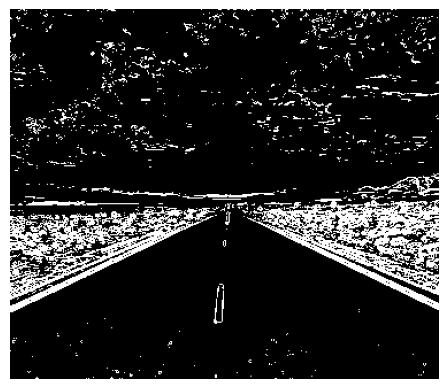

In [5]:
try:
    start_time = time.time()
    # === LOAD IMAGE ===
    img = cv.imread("Aula_6-7_files\\aula4-1.jpg")
    
    img_bgra = cv.cvtColor(img, cv.COLOR_BGR2BGRA)
    h, w, c = img_bgra.shape
    t1 = 100
    t2 = 50

    fmt = cl.ImageFormat(cl.channel_order.RGBA, cl.channel_type.UNSIGNED_INT8)

    imageIn = cl.create_image(ctx, cl.mem_flags.READ_ONLY | cl.mem_flags.COPY_HOST_PTR, fmt, shape=(w, h), hostbuf=img_bgra)

    output = np.empty_like(img_bgra)
    out_buf = cl.Buffer(ctx, cl.mem_flags.WRITE_ONLY, output.nbytes)

    kernel = prog.sobel

    kernel.set_arg(0, np.int32(w))
    kernel.set_arg(1, np.int32(h))
    kernel.set_arg(2, np.int32(t1))
    kernel.set_arg(3, np.int32(t2))
    kernel.set_arg(4, imageIn)
    kernel.set_arg(5, out_buf)

    
    #local_work_size_var  = [32, 32]
    #One PC has max work_size of 32, another has a max work_size of 16 

    local_work_size_var  = [16, 16]
    cl.enqueue_nd_range_kernel(commQ, kernel, global_work_size=(int(np.ceil(w/local_work_size_var[0]))*local_work_size_var[0], int(np.ceil(h/local_work_size_var[1]))*local_work_size_var[1]), local_work_size=local_work_size_var)
    #cl.enqueue_nd_range_kernel(commQ, kernel, global_work_size=[96, 400], local_work_size=[32, 8])
    cl.enqueue_copy(commQ, output, out_buf)
    commQ.finish()

    # Reshape and show result
    img_out = output.reshape(h, w, 4)

    execute_time_sobel_gpu = time.time() - start_time
    print(f"- gpu: execute --- {execute_time_sobel_gpu} seconds ---")

    plt.imshow(img_out)
    plt.axis('off')
    plt.show()


except Exception as e:
    print("Error:", e)

- cpu: execute --- 0.020867586135864258 seconds ---


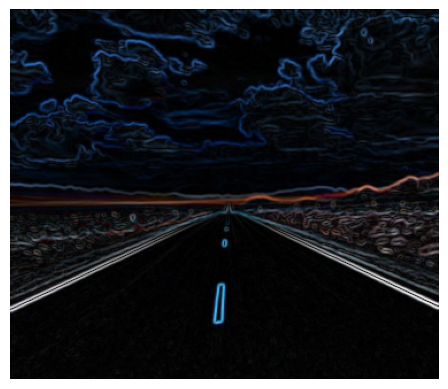

In [6]:
start_time = time.time()
img = cv.imread("Aula_6-7_files\\aula4-1.jpg")

if img is None:
    raise FileNotFoundError("Image not found. Check the path.")

# Convert to BGRA (adds alpha channel)
#img_rgba = cv.cvtColor(img, cv.COLOR_BGR2BGRA)

# === APPLY SOBEL ===

# Calculation of Sobelx
sobelx = cv.Sobel(img,cv.CV_64F,1,0,ksize=5)

# Calculation of Sobely
sobely = cv.Sobel(img,cv.CV_64F,0,1,ksize=5)

# Calculation of Laplacian
#laplacian = cv.Laplacian(hsv,cv.CV_64F)
grad = np.sqrt(np.power(sobelx, 2) + np.power(sobely, 2))

laplacian = (grad * 255 / grad.max()).astype(np.uint8)

execute_time_sobel_cpu = time.time() - start_time
print(f"- cpu: execute --- {execute_time_sobel_cpu} seconds ---")

# === SHOW RESULT ===
plt.imshow(laplacian)
plt.axis('off')
plt.show()


In [7]:
print(f"- Compare gpu exec. time with cpu exec. time --- {execute_time_sobel_gpu - execute_time_sobel_cpu} seconds ---")

- Compare gpu exec. time with cpu exec. time --- -0.01469111442565918 seconds ---


As the previous output is negative then it is reasonable to assume that the GPU execution time is smaller than the CPU execution time, meaning the opncv function is slower in this scenario, even though the gpu side has a black and white filter implemented and the cpu doesn't.